### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [112]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
!ls /content/drive/MyDrive/Colab_Notebooks/homework12/subset_homework/

class_id_0  class_id_1


In [114]:
import os
import numpy as np
import cv2
from time import time
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

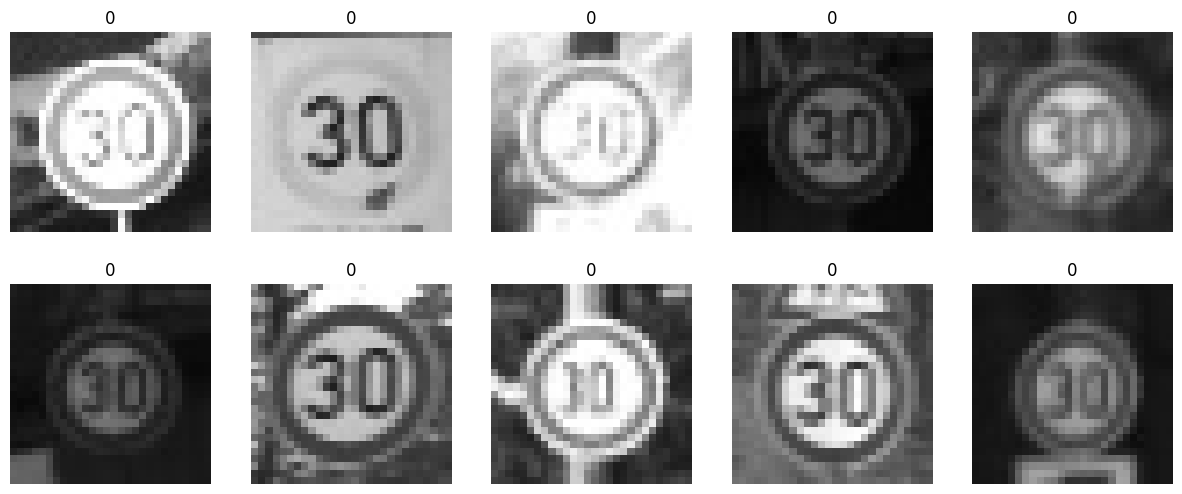

In [115]:
folder = '/content/drive/MyDrive/Colab_Notebooks/homework12/subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

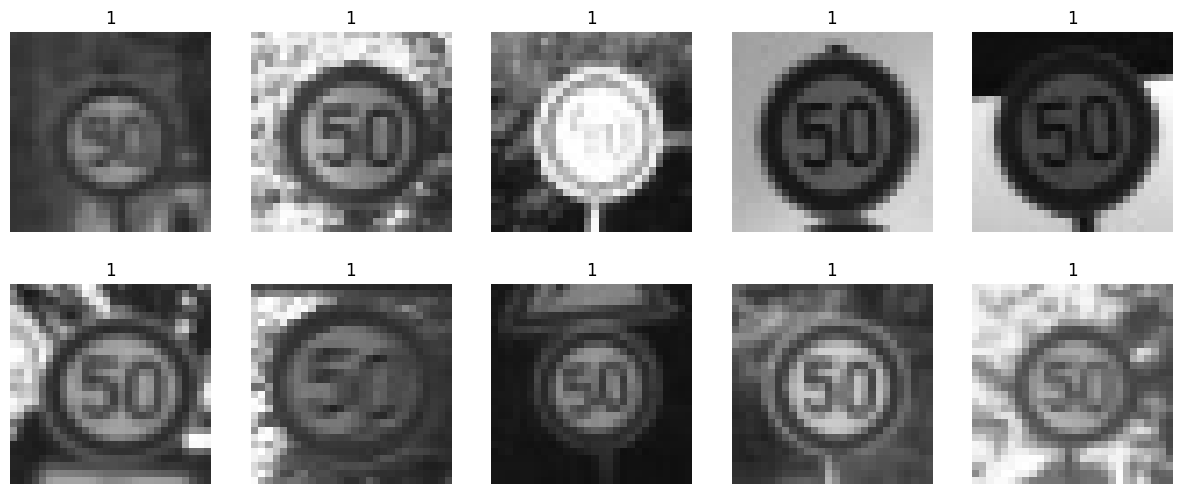

In [116]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [117]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))

Num samples class_0 2220
Num samples class_1 2250


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [118]:
# Put both classes together and shuffle the data
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.

In [119]:
start = time()
pixels = []
for image in images:
    pixels_ = []
    for r in range(image.shape[0]):
        for c in range(image.shape[1]):
            pixels_.append(image[r,c])
    pixels.append(pixels_)

pixels = np.array(pixels)/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 1.3879644870758057


Or, you know, just let make use of our friend numpy :-)

In [120]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (4470, 784)
Elapsed time 0.022011280059814453


Before the training, let's again have a look at some raqndom samples from our dataset.

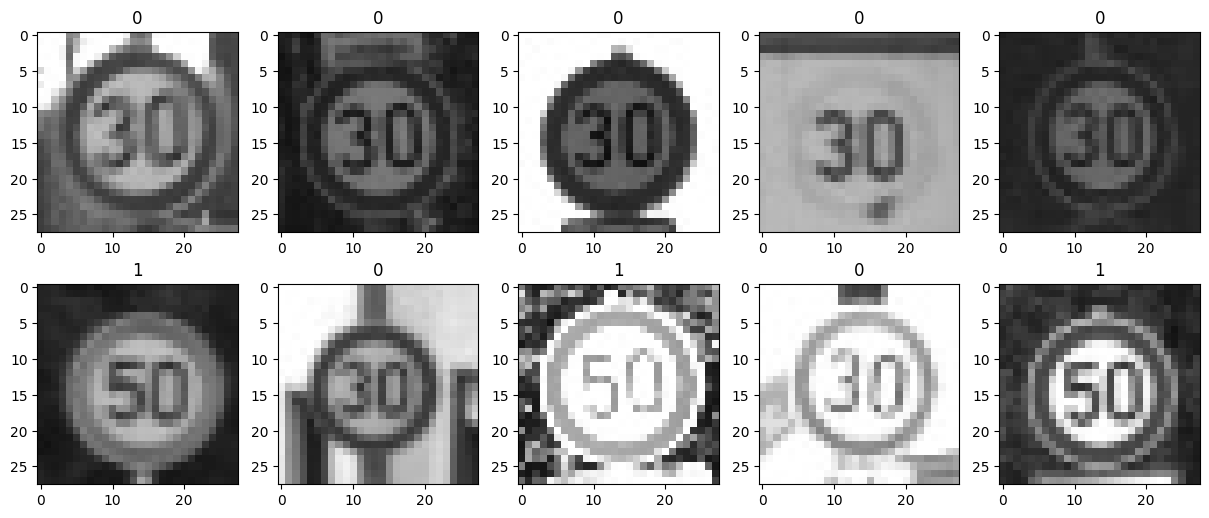

In [121]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [122]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [123]:
inputs = Input(shape=[pixels.shape[1]])
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

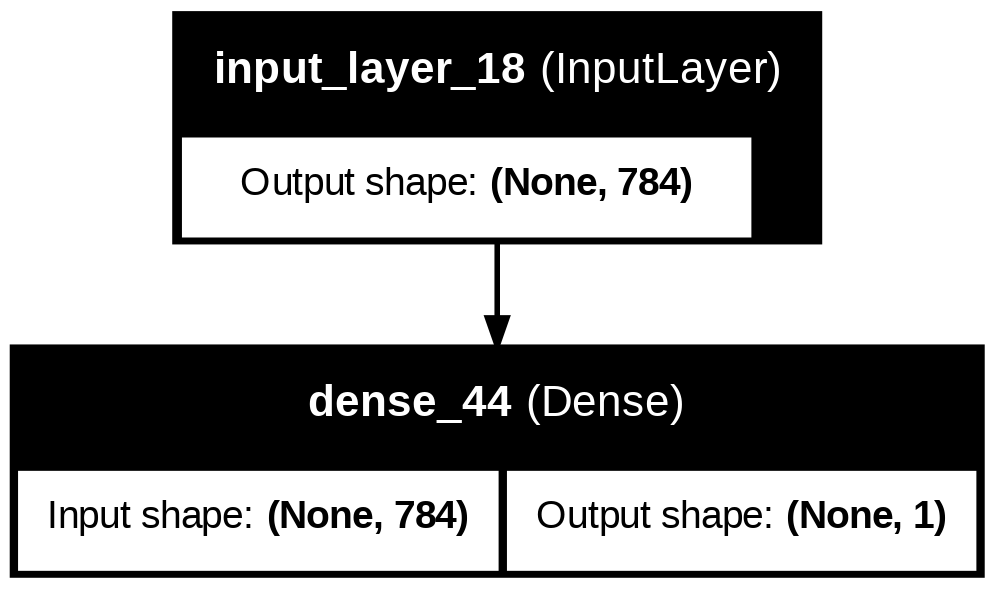

In [124]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [125]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

And let's train :-)

In [126]:
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4644
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2698
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2107
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1792
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1576
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1472
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1255
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1207
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1096
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1049


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

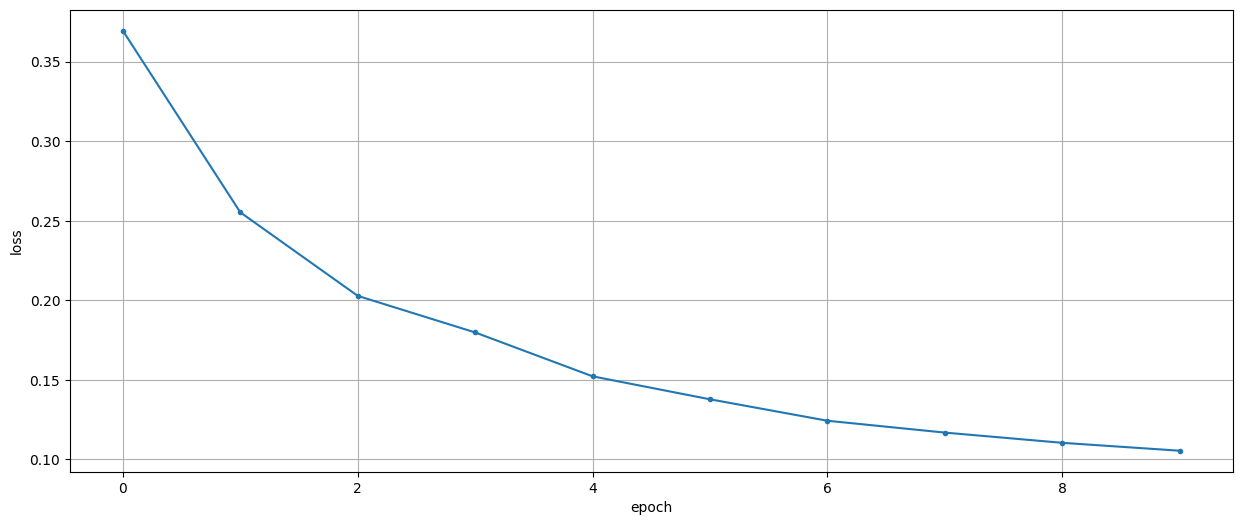

In [127]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.39949313] [0.39949313]


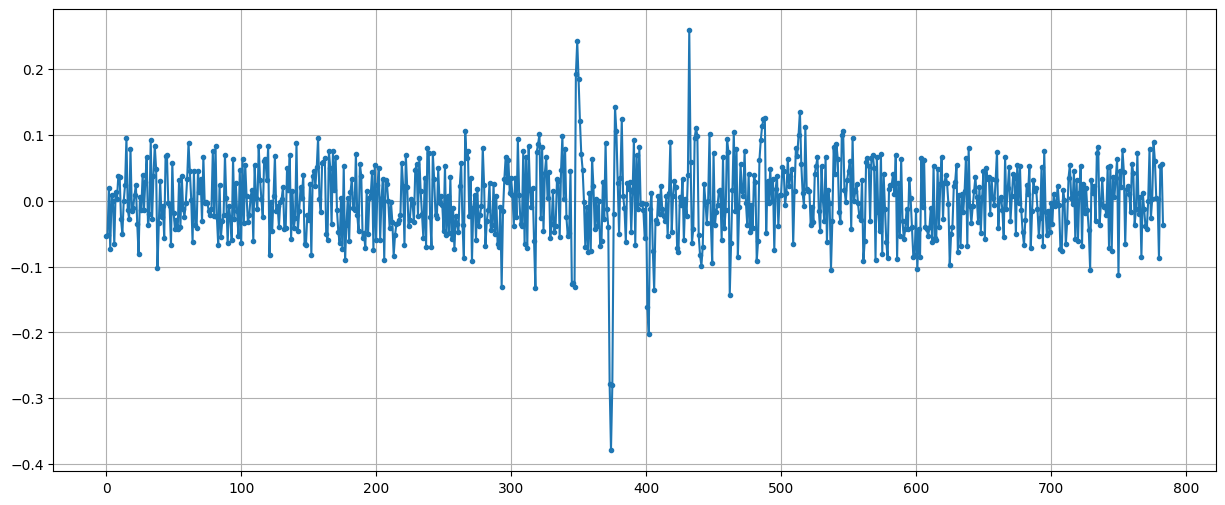

In [128]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [129]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[[-0.1703504]] 0


In [130]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [131]:
original__accuracy = None
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

original__accuracy = correct/len(labels)
print('Accuracy', original__accuracy)

Accuracy 0.9109619686800895


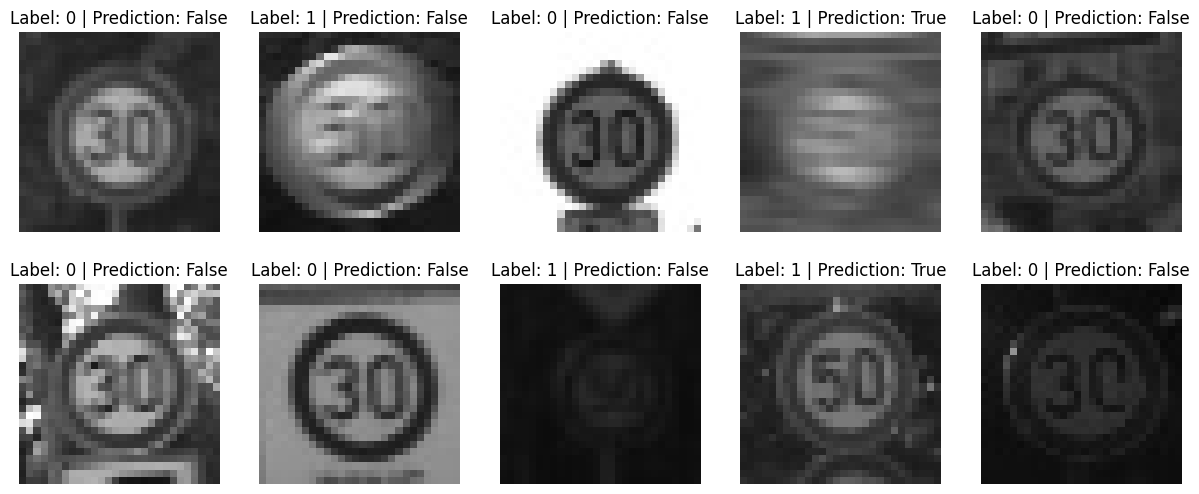

In [132]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)

# Homework part

## Improvement 1: Add more neurons

---



In [133]:
# try with 3 neurons
inputs = Input(shape=[pixels.shape[1]])
hidden = Dense(3, activation="linear")(inputs)
# since the output this layer will be (, 3) we need to add additional layer
# that will transform its shape into (,1)
outputs = Dense(1, activation="linear")(hidden)
model = Model(inputs, outputs)

model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 3)              │         2,355 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,359 (9.21 KB)

 Trainable params: 2,359 (9.21 KB)

 Non-trainable params: 0 (0.00 B)

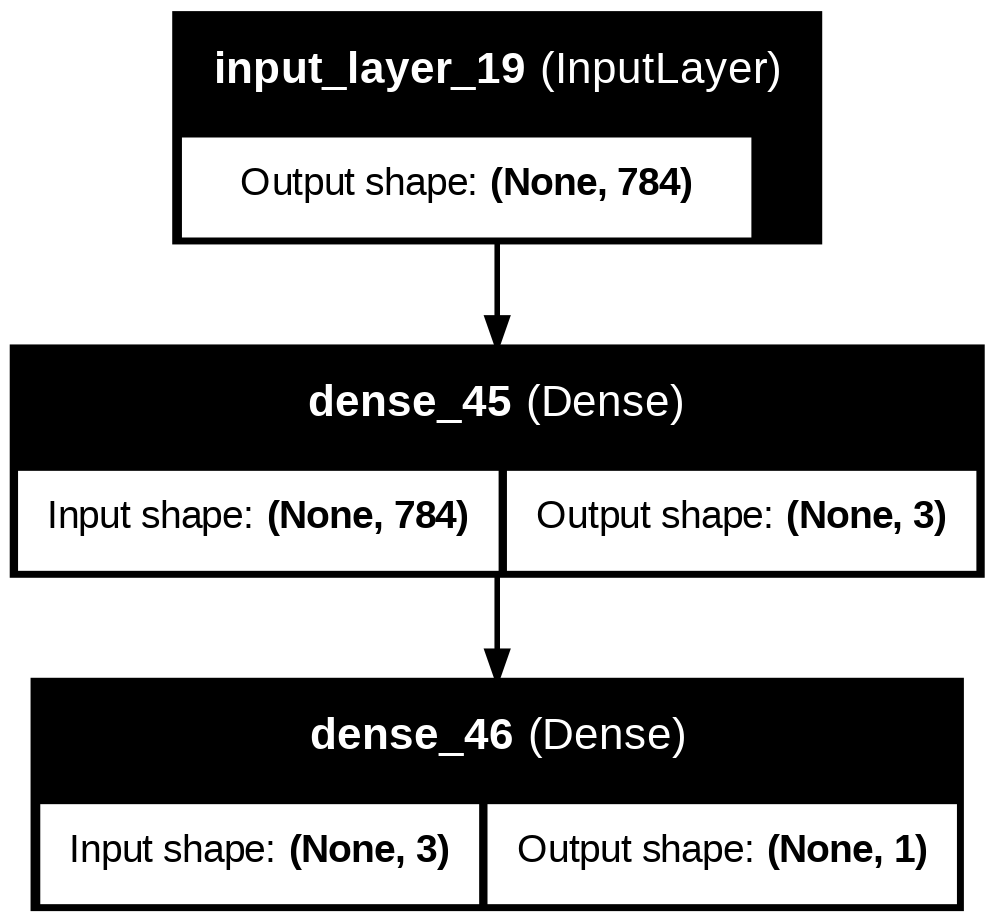

In [134]:
# visualize it
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [135]:
# compile and train
model.compile(optimizer ='adam', loss = 'mean_squared_error')
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5552
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2065
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1652
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1513
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1190
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1142
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0994
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1026
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0985
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0999


In [136]:
# let's check if performance is improved
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

improved_accuracy_1 = None
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

improved_accuracy_1 = correct/len(labels)
print('Original accuracy', original__accuracy)
print("Improved accuracy 1", improved_accuracy_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[-0.29655826]] 0
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Original accuracy 0.9109619686800895
Improved accuracy 1 0.9199105145413871


It improved a little bit.

## Improvement 2: Try differet activation function and Adamax

Let's add more neurons and layers with different activation functions. Also let's try Adamax optimizator.

In [137]:
inputs = Input(shape=[pixels.shape[1]])
hidden_1 = Dense(10, activation="linear")(inputs)
hidden_2 = Dense(10, activation="softmax")(hidden_1)
hidden_3 = Dense(10, activation="sigmoid")(hidden_2)
outputs = Dense(1, activation="linear")(hidden_3)
model = Model(inputs, outputs)

model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,081 (31.57 KB)

 Trainable params: 8,081 (31.57 KB)

 Non-trainable params: 0 (0.00 B)

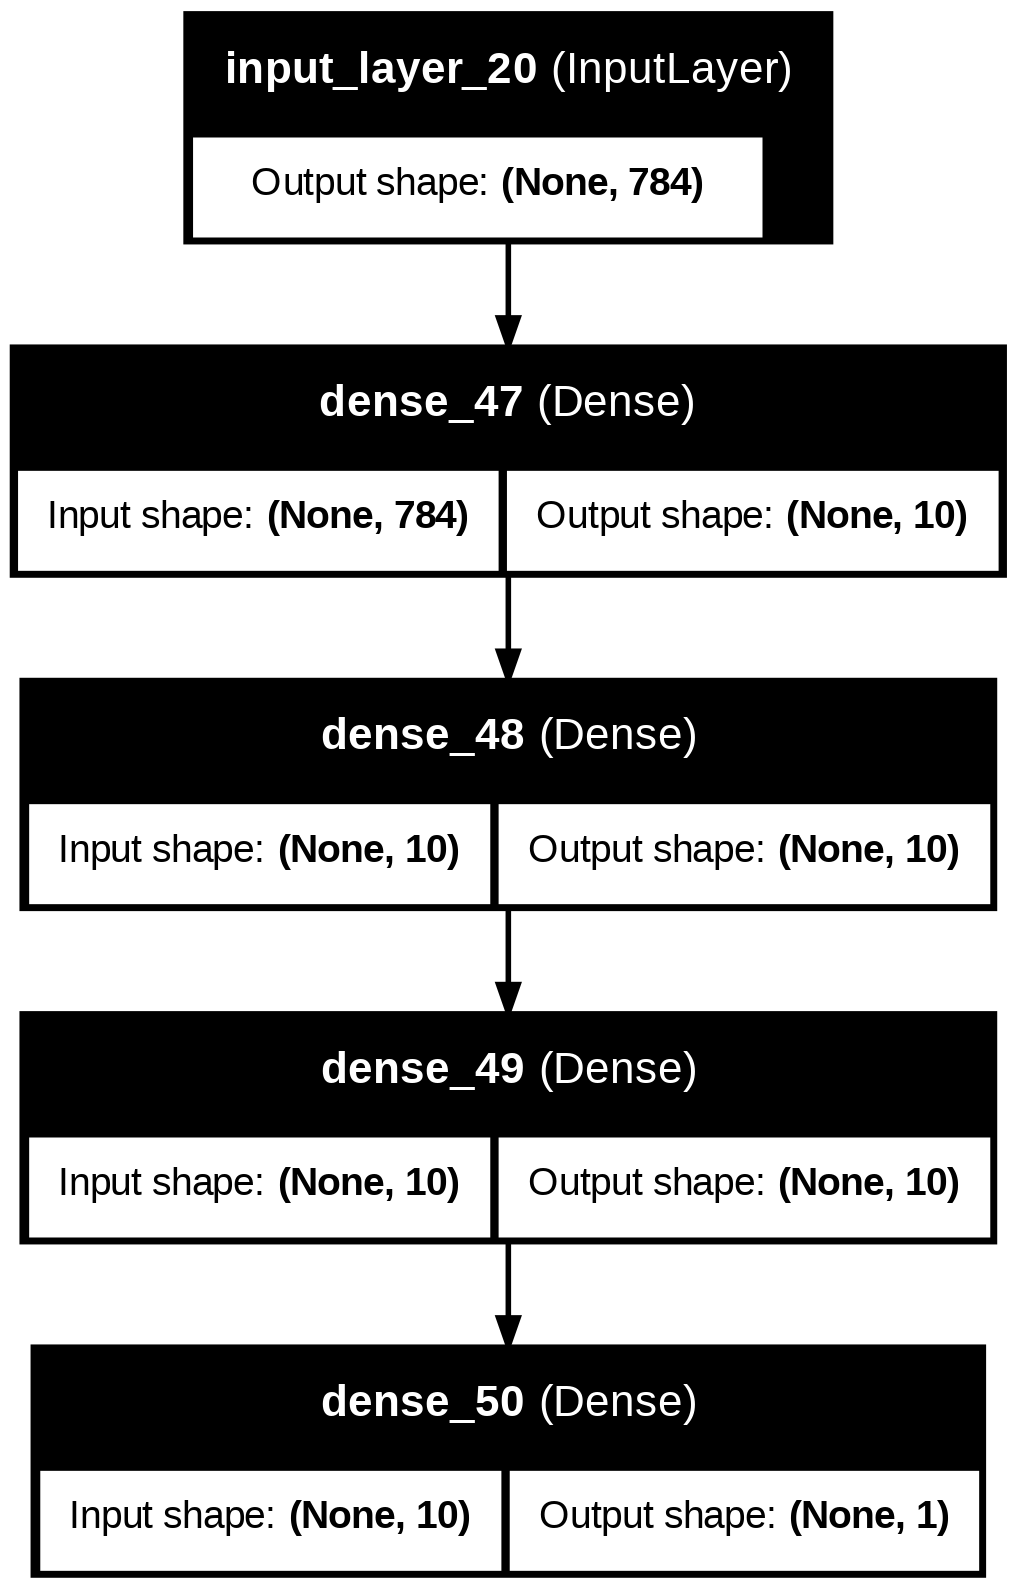

In [138]:
# visualize it
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [139]:
# compile and train
model.compile(optimizer ='adamax', loss = 'mean_squared_error')
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0513
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3411
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2561
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2493
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2488
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2479
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2482
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2470
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2432
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2318


In [140]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

improved_accuracy_2 = None
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

improved_accuracy_2 = correct/len(labels)
print('Original accuracy', original__accuracy)
print("Improved accuracy 1", improved_accuracy_1)
print("Improved accuracy 2", improved_accuracy_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
[[0.34946674]] 0
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Original accuracy 0.9109619686800895
Improved accuracy 1 0.9199105145413871
Improved accuracy 2 0.6762863534675615


Accuracy is drastically decreased. Maybe mixing different activation functions is not good approach.

## Improvement 3: Single activation function

Let's try to use three layers but only softmax activation function.

In [141]:
inputs = Input(shape=[pixels.shape[1]])
hidden_1 = Dense(10, activation="softmax")(inputs)
hidden_2 = Dense(10, activation="softmax")(hidden_1)
hidden_3 = Dense(10, activation="softmax")(hidden_2)
outputs = Dense(1, activation="softmax")(hidden_3)
model = Model(inputs, outputs)

model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,081 (31.57 KB)

 Trainable params: 8,081 (31.57 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
# let's try more epochs and the larger batch size this time
model.compile(optimizer ='adamax', loss = 'mean_squared_error')
history = model.fit(pixels, labels, epochs=20, batch_size=32)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4845
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4975
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5058
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5024
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4954
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4882
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4964
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5018
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4929
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4910
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4907
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4897
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4996
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4960
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5015


In [143]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

improved_accuracy_3 = None
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

improved_accuracy_3 = correct/len(labels)
print('Original accuracy', original__accuracy)
print("Improved accuracy 1", improved_accuracy_1)
print("Improved accuracy 2", improved_accuracy_2)
print("Improved accuracy 3", improved_accuracy_3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[1.]] 0
  1/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Original accuracy 0.9109619686800895
Improved accuracy 1 0.9199105145413871
Improved accuracy 2 0.6762863534675615
Improved accuracy 3 0.5033557046979866


The first improvement is still the best.

## Improvement 4: First improvement with bias

Let's try the first improvement with bias.

In [144]:
inputs = Input(shape=[pixels.shape[1]])
hidden = Dense(3, activation="linear", use_bias=True, bias_initializer=tf.keras.initializers.Constant(value=0.1))(inputs)
outputs = Dense(1, activation="linear")(hidden)
model = Model(inputs, outputs)

model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 3)              │         2,355 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,359 (9.21 KB)

 Trainable params: 2,359 (9.21 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
# compile and train
model.compile(optimizer ='adam', loss = 'mean_squared_error')
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4238
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2257
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1696
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1272
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1149
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1072
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0986
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1020
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0959
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1079


In [146]:
idx = 50
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

improved_accuracy_4 = None
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

improved_accuracy_4 = correct/len(labels)
print('Original accuracy', original__accuracy)
print("Improved accuracy 1", improved_accuracy_1)
print("Improved accuracy 2", improved_accuracy_2)
print("Improved accuracy 3", improved_accuracy_3)
print("Improved accuracy 4", improved_accuracy_4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[-0.3944639]] 0
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Original accuracy 0.9109619686800895
Improved accuracy 1 0.9199105145413871
Improved accuracy 2 0.6762863534675615
Improved accuracy 3 0.5033557046979866
Improved accuracy 4 0.946979865771812
